# Exercise 1 (20 points) 

Please state **True** or **False** for the below statements.

- (a) Linear programming requires all decision variables to be integers. 

- (b) MLDTs are typically used in the Predictive Analytics phase, while DADTs are used in Prescriptive Analytics. 

- (c) In a DADT, prior probabilities can reflect expert opinion or subjective judgment. 

- (d) The structure of a DADT must be known in advance and is not learned from data.  

- (e) Menu generation can be modeled using binary integer programming. 

- (f) Constraint programming is the same as integer programming. 

- (g) The `linprog()` function in SciPy is used for solving nonlinear programming problems. 

- (h) A feasible region can never be empty in a linear programming problem. 

- (i) The objective function in a linear programming model can be nonlinear. 

- (j) The presence of probabilities in a DADT implies it is a stochastic simulation. 

a. False

b. True

c. True

d. True

e. True

f. False

g. False

h. False

i. False

j. False

# Exercise 2 (4 points)

What makes probabilities in a DADT subjective rather than objective? Please be specific.

They are subjective because they are based on judgment, beliefs, or expert opinions rather than on real data.

# Exercise 3 (4 points)

In a maximization problem handled by SciPy, what transformation must be applied?

- (a) Multiply constraints by −1
- (b) Take logarithms of variables
- (c) Square the coefficients
- (d) Multiply the objective coefficients by −1
- (e) All of the above


D

# Exercise 4 (4 points)

What is the role of sensitivity analysis in mathematical programming? Please be specific.

It allows us to see how the solution of the model changes based on changes to input parameters. These changes can be made to test "what-if" scenarios and identify key parameters.

# Exercise 5 (4 points)

Which is **NOT** a characteristic of a Decision Analysis Decision Tree (DADT)?

- (a) Subjective probabilities
- (b) Data-driven bifurcation
- (c) Time orientation
- (d) Scenario-based reasoning
- (e) None of the above

B

# Exercise 6 (5 points)

Describe how a DADT accounts for the time dimension in decision-making. Please be specific.

DADTs account for time by modeling sequences of events, decisions, and outcomes over time

# Exercise 7 (5 points)

Write a Python function that simulates the Bass Diffusion curve using values `p=0.03`, `q=0.38` for 36 months. Plot the curve.

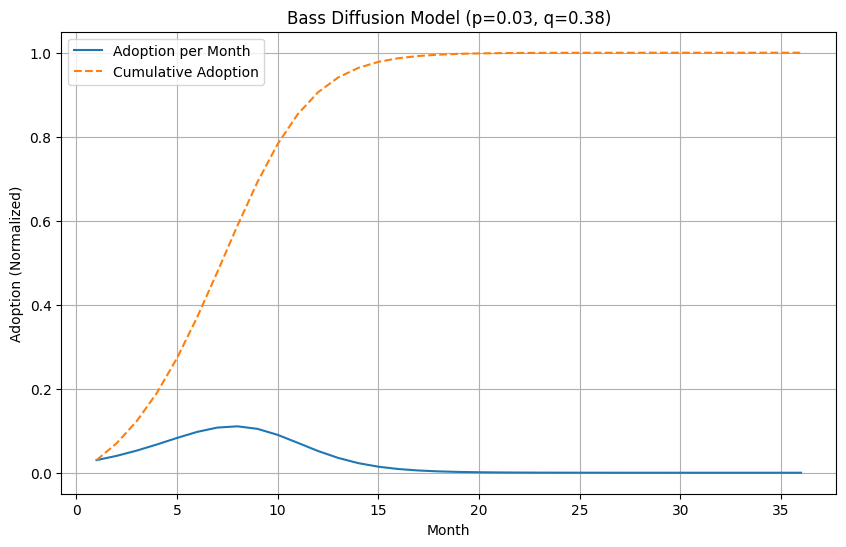

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_bass_diffusion(p=0.03, q=0.38, m=1.0, periods=36):
    adoption = np.zeros(periods)
    cumulative_adoption = np.zeros(periods)

    for t in range(periods):
        if t == 0:
            adoption[t] = p * m
        else:
            adoption[t] = (p + q * (cumulative_adoption[t-1] / m)) * (m - cumulative_adoption[t-1])
        cumulative_adoption[t] = cumulative_adoption[t-1] + adoption[t]

    # Plot
    months = np.arange(1, periods + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(months, adoption, label='Adoption per Month')
    plt.plot(months, cumulative_adoption, label='Cumulative Adoption', linestyle='--')
    plt.title('Bass Diffusion Model (p=0.03, q=0.38)')
    plt.xlabel('Month')
    plt.ylabel('Adoption (Normalized)')
    plt.legend()
    plt.grid(True)
    plt.show()


simulate_bass_diffusion()

# Exercise 8 (4 points)

What does the Central Limit Theorem support in simulation results?

- (a) Independence of variables
- (b) Linear regression validity
- (c) Normality of sampling distribution
- (d) Convergence of time series
- (e) None of the above

C

# Exercise 9 (5 points)

How does simulation address uncertainty in mathematical programming? Please be specific.

It allows decision makers to evaluate the model under a various range of possible inputs rather than just single value estimates

# Exercise 10 (5 points)

What does convergence in a simulation indicate? Please, be specific.

Convergence indicates the results are approaching their expected values and the output metrics are stabalizing as the number of simulations run

# Exercise 11 (4 points)

In a stochastic simulation, what do Key Performance Metrics (KPMs) typically measure?

- (a) Memory usage
- (b) Employee satisfaction
- (c) Simulation outcomes
- (d) Marketing impact only
- (e) All of the above

C

# Exercise 12 (5 points)

What are the benefits and limitations of using stochastic simulations in business analytics? Please, be specific.

Stocastic simulations allows you to model uncertanty and give instight to potential risks and variablility in different business events. But they require reliable historical data and requires expert interpretation which can be limitations

# Exercise 13 (7 points)

Simulate 1,000 sample means from a normal distribution (you select the mean and standard deviation) and compute 95% confidence intervals for the population mean. 

Confidence intervals that contain the true mean: 949 / 1000


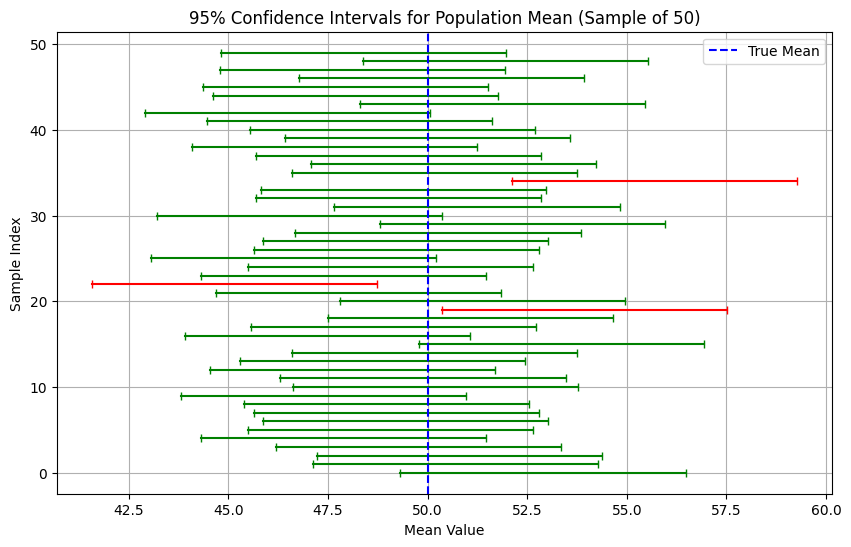

In [ ]:
import scipy.stats as stats

# Params
mean = 50
std = 10
sample_size = 30
num_simulations = 1000
confidence_level = 0.95

sample_means = []
conf_intervals = []

z_critical = stats.norm.ppf(1 - (1 - confidence_level)/2)

for _ in range(num_simulations):
    sample = np.random.normal(loc=mean, scale=std, size=sample_size)
    sample_mean = np.mean(sample)
    standard_error = std / np.sqrt(sample_size)

    margin_of_error = z_critical * standard_error
    ci_lower = sample_mean - margin_of_error
    ci_upper = sample_mean + margin_of_error

    sample_means.append(sample_mean)
    conf_intervals.append((ci_lower, ci_upper))

count_containing_mean = sum(1 for ci in conf_intervals if ci[0] <= mean <= ci[1])
print(f"Confidence intervals that contain the true mean: {count_containing_mean} / {num_simulations}")

# Plotting 
plt.figure(figsize=(10, 6))
for i in range(50):
    lower, upper = conf_intervals[i]
    contains = lower <= mean <= upper
    color = 'green' if contains else 'red'
    plt.plot([lower, upper], [i, i], color=color, marker='|')
plt.axvline(mean, color='blue', linestyle='--', label='True Mean')
plt.title('95% Confidence Intervals for Population Mean (Sample of 50)')
plt.xlabel('Mean Value')
plt.ylabel('Sample Index')
plt.legend()
plt.grid(True)
plt.show()

# Exercise 14 (7 points)

Simulate 1000 times the NPV of a project over 10 years using random yearly revenue values drawn from a triangular distribution (consider the following configuration: worst case = $8\cdot10^6$, most likely case = $10\cdot10^6$, best case = $12\cdot10^6$). Plot the distribution.

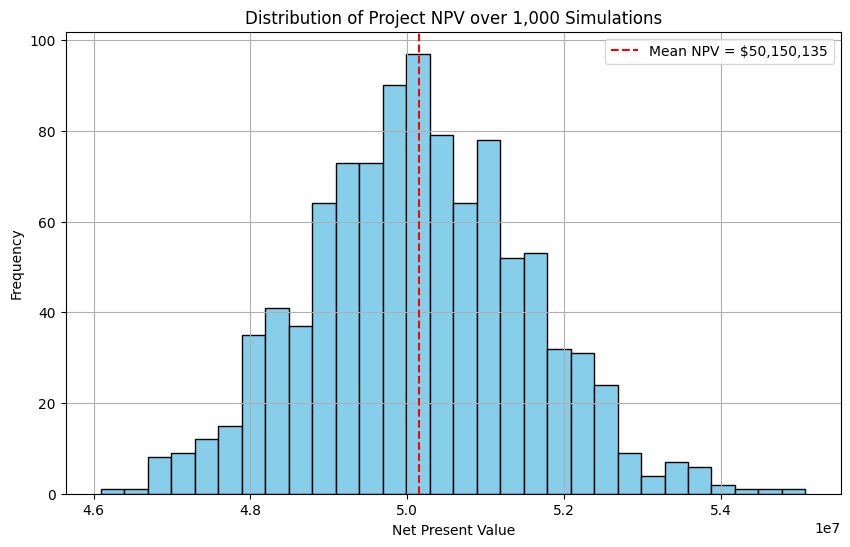

In [ ]:
worst_case = 8e6
most_likely = 10e6
best_case = 12e6
years = 10
discount_rate = 0.15
num_simulations = 1000

# discount factors
discount_factors = np.array([(1 / (1 + discount_rate))**t for t in range(1, years + 1)])

npvs = []

for _ in range(num_simulations):
    # Draw 10 random revenues 
    annual_revenues = np.random.triangular(worst_case, most_likely, best_case, size=years)
    
    # Discounted cash flows
    discounted_revenues = annual_revenues * discount_factors
    
    # Compute NPV 
    npv = np.sum(discounted_revenues)
    npvs.append(npv)

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(npvs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(np.mean(npvs), color='red', linestyle='--', label=f"Mean NPV = ${np.mean(npvs):,.0f}")
plt.title("Distribution of Project NPV over 1,000 Simulations")
plt.xlabel("Net Present Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()